<a href="https://colab.research.google.com/github/PacktPublishing/Modern-Computer-Vision-with-PyTorch-2E/blob/main/Chapter13/Image_super_resolution_using_SRGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
%pip install PyDrive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 21.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for PyDrive: filename=PyDrive-1.3.1-py3-none-any.whl size=27433 sha256=5b14511f9479ba68e476cfc75da3567c18ac697739033c9af47e6974ebe351f1
  Stored in directory: /root/.cache/pip/wheels/6c/10/da/a5b513f5b3916fc391c20ee7b4633e5cf3396d570cdd74970f
Successfully built PyDrive


In [6]:
import google.colab

In [8]:
# import os
# if not os.path.exists('srgan.pth.tar'):
#     %pip install -q torch_snippets
#     !wget -q https://raw.githubusercontent.com/sizhky/a-PyTorch-Tutorial-to-Super-Resolution/master/models.py -O models.py
#     from pydrive.auth import GoogleAuth
#     from pydrive.drive import GoogleDrive
#     from google.colab import auth
#     from oauth2client.client import GoogleCredentials

#     auth.authenticate_user()
#     gauth = GoogleAuth()
#     gauth.credentials = GoogleCredentials.get_application_default()
#     drive = GoogleDrive(gauth)

#     downloaded = drive.CreateFile({'id': '1_PJ1Uimbr0xrPjE8U3Q_bG7XycGgsbVo'})
#     downloaded.GetContentFile('srgan.pth.tar')
#     from torch_snippets import *
#     device = 'cuda' if torch.cuda.is_available() else 'cpu'
import os

if not os.path.exists('srgan.pth.tar'):
    %pip install -q torch_snippets gdown

    !wget -q https://raw.githubusercontent.com/sizhky/a-PyTorch-Tutorial-to-Super-Resolution/master/models.py -O models.py

    import gdown

    file_id = "1_PJ1Uimbr0xrPjE8U3Q_bG7XycGgsbVo"
    gdown.download(
        f"https://drive.google.com/uc?id={file_id}",
        "srgan.pth.tar",
        quiet=False
    )

from torch_snippets import *
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

Downloading...
From: https://drive.google.com/uc?id=1_PJ1Uimbr0xrPjE8U3Q_bG7XycGgsbVo
To: /content/srgan.pth.tar
100%|██████████| 101M/101M [00:00<00:00, 123MB/s] 


In [10]:
from models import Generator

checkpoint = torch.load(
    'srgan.pth.tar',
    map_location='cpu',
    weights_only=False
)

model = checkpoint['generator'].to(device)
model.eval()

/content/models.py:255: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  out_channels = (n_channels if i is 0 else in_channels * 2) if i % 2 is 0 else in_channels
/content/models.py:255: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  out_channels = (n_channels if i is 0 else in_channels * 2) if i % 2 is 0 else in_channels
/content/models.py:258: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  stride=1 if i % 2 is 0 else 2, batch_norm=i is not 0, activation='LeakyReLu'))
/content/models.py:258: SyntaxWarning: "is not" with 'int' literal. Did you mean "!="?
  stride=1 if i % 2 is 0 else 2, batch_norm=i is not 0, activation='LeakyReLu'))
/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1782: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool t

Generator(
  (net): SRResNet(
    (conv_block1): ConvolutionalBlock(
      (conv_block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
        (1): PReLU(num_parameters=1)
      )
    )
    (residual_blocks): Sequential(
      (0): ResidualBlock(
        (conv_block1): ConvolutionalBlock(
          (conv_block): Sequential(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): PReLU(num_parameters=1)
          )
        )
        (conv_block2): ConvolutionalBlock(
          (conv_block): Sequential(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
      )
      (1): ResidualBlock(
        (conv_block1): ConvolutionalBlock(
          (conv_block): Seque

In [11]:
!wget -q https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg -O MyImage.jpg

In [13]:
preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
    T.Lambda(lambda x: x.to(device))
])

postprocess = T.Compose([
    T.Lambda(lambda x: (x.cpu().detach()+1)/2),
    T.ToPILImage()
])

In [14]:
image = readPIL('MyImage.jpg')
w, h = image.size
reduction_factor = 4
image = image.resize((w//reduction_factor,h//reduction_factor))
im = preprocess(image)

In [15]:
sr = model(im[None])[0]
sr = postprocess(sr)

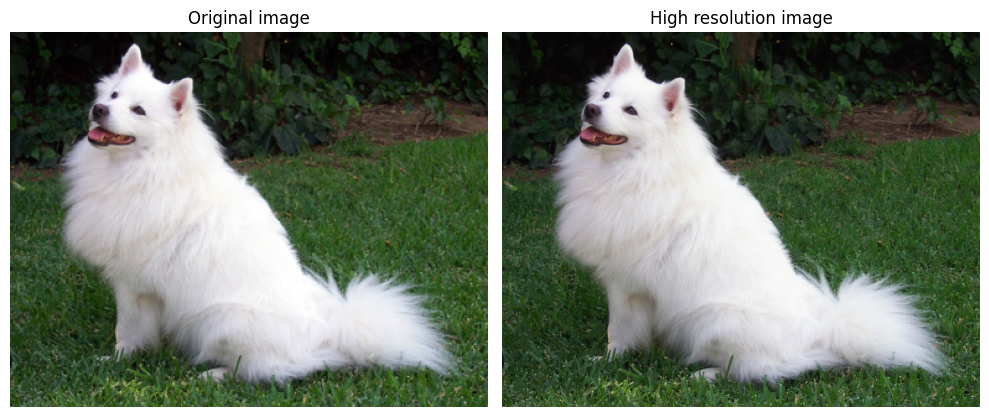

In [16]:
subplots([image, sr], nc=2, figsize=(10,10), titles=['Original image','High resolution image'])